# 01. Silver Label EDA and Suspiciousness Definition

This notebook checks the session-level data structure and explains why `cluster_number == 1` can be used as a weak suspicious signal.

Important: `cluster_number` is not ground truth. It is only a silver label from KMeans, used as an initial proxy for viewer-chat mismatch.

## Project Framing

There is no verified ground-truth label for actual viewbot usage. Therefore, this project should not claim to automatically prove viewbot usage.

The practical goal is to reduce the number of broadcasts that a human reviewer must inspect. The model produces suspiciousness scores and review candidates, not final judgments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42

## 1. Load Data

In [2]:
from pathlib import Path

def find_project_root(start=None):
    """Find the project root from either the root folder or the notebooks folder."""
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'csv' / 'session_summary_processed.csv').exists():
            return p
    raise FileNotFoundError('Could not find csv/session_summary_processed.csv. Run this notebook from the project folder.')

PROJECT_ROOT = find_project_root()
CSV_DIR = PROJECT_ROOT / 'csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

PROJECT_ROOT

WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델')

In [3]:
session = pd.read_csv(CSV_DIR / 'session_summary_processed.csv')
minute_model = pd.read_csv(CSV_DIR / 'minute_model.csv')
minute_all = pd.read_csv(CSV_DIR / 'minute_all.csv')

for col in ['start', 'end']:
    session[col] = pd.to_datetime(session[col], errors='coerce')
minute_model['minute_ts'] = pd.to_datetime(minute_model['minute_ts'], errors='coerce')
minute_all['minute_ts'] = pd.to_datetime(minute_all['minute_ts'], errors='coerce')

print('session:', session.shape)
print('minute_model:', minute_model.shape)
print('minute_all:', minute_all.shape)
session.head()

session: (1954, 21)
minute_model: (207072, 10)
minute_all: (215824, 10)


,run_id,broad_no,session_key,user_id,category_id,n,start,end,viewer_med,viewer_max,chat_mean,unique_mean,zero_rate,zrun_max,gap_med,gap_max,log_viewer,log_chat,log_unique,log_zrun,cluster_number
0,31,18296919,31_18296919,7de18e974bc4bbbe6737d941b72aa2f8,던전앤파이터,119,2026-04-14 17:00:00,2026-04-14 19:00:00,221.0000,258.0000,0.2101,0.1092,0.8908,9,5.3936,5.5568,5.4027,0.1907,0.1037,2.3026,1
1,31,18350777,31_18350777,b628d1039a84ecc703804e17acee2eb3,리그 오브 레전드,121,2026-04-14 17:00:00,2026-04-14 19:00:00,235.0000,288.0000,7.6116,4.7025,0.0909,2,3.4500,5.5759,5.4638,2.1531,1.7409,1.0986,0
2,31,18351042,31_18351042,d29db9ee45bf3b5e5b099c6b3c54b443,로스트아크,119,2026-04-14 17:00:00,2026-04-14 18:58:00,333.0000,383.0000,11.1681,6.8824,0.0252,2,3.5041,5.9108,5.8111,2.4988,2.0646,1.0986,0
3,31,18351670,31_18351670,dcfd3c7cf3c05b41306a4cc249ad5c9f,붉은사막,117,2026-04-14 17:00:00,2026-04-14 19:00:00,135.0000,159.0000,2.5641,1.8291,0.1624,2,3.7992,5.0370,4.9127,1.2709,1.0399,1.0986,0
4,31,18352554,31_18352554,14780be344c96ad0c272b51d0605dedb,로스트아크,121,2026-04-14 17:00:00,2026-04-14 19:00:00,361.0000,389.0000,39.3802,23.3140,0.0000,0,2.2744,3.4714,5.8916,3.6983,3.1911,0.0000,0


## 2. Entity Counts

The core entity is a broadcast session, identified by `session_key = run_id + broad_no`.

`user_id` is interpreted as the streamer or channel identifier, and `category_id` is interpreted as the broadcast category.

In [4]:
def entity_counts(df, name):
    cols = ['source_file', 'run_id', 'broad_no', 'session_key', 'user_id', 'category_id']
    rows = []
    for col in cols:
        if col in df.columns:
            rows.append({'dataset': name, 'entity': col, 'n_unique': df[col].nunique(dropna=True)})
    return pd.DataFrame(rows)

entity_table = pd.concat([
    entity_counts(minute_all, 'minute_all'),
    entity_counts(minute_model, 'minute_model'),
    entity_counts(session, 'session_summary_processed'),
], ignore_index=True)

entity_table

,dataset,entity,n_unique
0,minute_all,source_file,87
1,minute_all,run_id,87
2,minute_all,broad_no,1811
3,minute_all,session_key,2092
4,minute_all,user_id,513
5,minute_all,category_id,259
6,minute_model,source_file,87
7,minute_model,run_id,87
8,minute_model,broad_no,1730
9,minute_model,session_key,1997


In [5]:
summary_rows = [
    {
        'dataset': 'minute_all',
        'rows': len(minute_all),
        'sessions': minute_all['session_key'].nunique(),
        'start': minute_all['minute_ts'].min(),
        'end': minute_all['minute_ts'].max(),
    },
    {
        'dataset': 'minute_model',
        'rows': len(minute_model),
        'sessions': minute_model['session_key'].nunique(),
        'start': minute_model['minute_ts'].min(),
        'end': minute_model['minute_ts'].max(),
    },
    {
        'dataset': 'session_summary_processed',
        'rows': len(session),
        'sessions': session['session_key'].nunique(),
        'start': session['start'].min(),
        'end': session['end'].max(),
    },
]
summary_table = pd.DataFrame(summary_rows)
summary_table

,dataset,rows,sessions,start,end
0,minute_all,215824,2092,2026-04-14 17:00:00,2026-05-28 22:01:00
1,minute_model,207072,1997,2026-04-14 17:00:00,2026-05-28 22:01:00
2,session_summary_processed,1954,1954,2026-04-14 17:00:00,2026-05-28 22:01:00


## 3. Silver Label Definition

`cluster_number` is the result of KMeans clustering on session-level summary features.

In this notebook, `cluster_number == 1` is treated as a suspicious silver label because its profile shows weak chat response relative to viewer activity. It is not treated as a verified viewbot label.

In [6]:
session = session.copy()
session['silver_suspicious'] = (session['cluster_number'] == 1).astype(int)

cluster_counts = (
    session['cluster_number']
    .value_counts()
    .sort_index()
    .rename_axis('cluster_number')
    .reset_index(name='n_sessions')
)
cluster_counts['ratio'] = cluster_counts['n_sessions'] / len(session)
cluster_counts

,cluster_number,n_sessions,ratio
0,0,1843,0.9432
1,1,111,0.0568


In [7]:
profile_cols = [
    'n', 'viewer_med', 'viewer_max', 'chat_mean', 'unique_mean',
    'zero_rate', 'zrun_max', 'gap_med', 'gap_max',
    'log_viewer', 'log_chat', 'log_unique', 'log_zrun'
]

cluster_profile = (
    session
    .groupby('cluster_number')[profile_cols]
    .agg(['count', 'mean', 'median'])
    .round(4)
)
cluster_profile

n                   viewer_med                      \
               count     mean   median      count       mean   median   
cluster_number                                                          
0               1843 105.7727 121.0000       1843 1,838.3920 601.5000   
1                111 107.3874 119.0000        111   331.2027 161.0000   

               viewer_max                     chat_mean                  \
                    count       mean   median     count    mean  median   
cluster_number                                                            
0                    1843 2,299.3451 735.0000      1843 51.8651 24.8512   
1                     111   400.5315 191.0000       111  2.1168  1.5763   

               unique_mean                 zero_rate               zrun_max  \
                     count    mean  median     count   mean median    count   
cluster_number                                                                
0                     1843 28.7218 14.9508      1843 0.0241 0.0000     1843   
1                      111  1.4079  1.1008       111 0.5088 0.4615      111   

                              gap_med               gap_max                \
                  mean median   count   mean median   count   mean median   
cluster_number                                                              
0               0.7363 0.0000    1843 3.3826 3.3750    1843 5.4221 5.4279   
1              11.8739 8.0000     111 4.8793 4.5924     111 5.5417 5.1985   

               log_viewer               log_chat               log_unique  \
                    count   mean median    count   mean median      count   
cluster_number                                                              
0                    1843 6.5460 6.4011     1843 3.3319 3.2524       1843   
1                     111 5.3997 5.0876      111 0.9313 0.9463        111   

                             log_zrun                
                 mean median    count   mean median  
cluster_number                                       
0              2.8473 2.7695     1843 0.3773 0.0000  
1              0.7530 0.7423      111 2.3339 2.1972

The most important columns for interpretation are:

- `zero_rate`: fraction of minutes with zero chat
- `zrun_max`: longest consecutive zero-chat run
- `gap_med`: median of `log1p(viewer_count_last) - log1p(chat_count)`
- `chat_mean`, `unique_mean`: average chat activity per minute

A viewbot-like pattern should have a direction: viewers exist, but chat reaction is weak. This is different from generic anomaly detection.

## 4. Feature Distributions

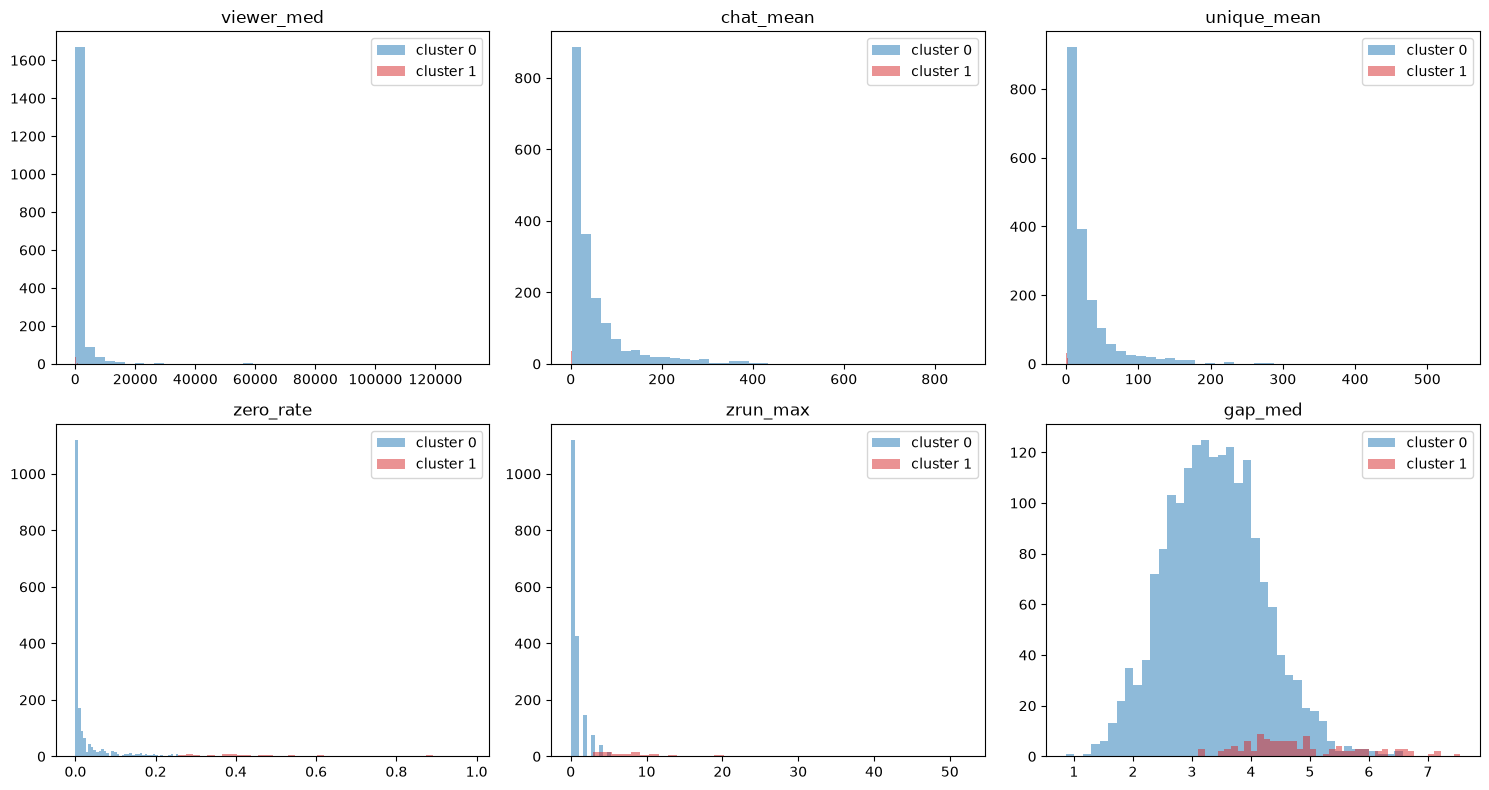

In [8]:
plot_cols = ['viewer_med', 'chat_mean', 'unique_mean', 'zero_rate', 'zrun_max', 'gap_med']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    for c, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        values = session.loc[session['cluster_number'] == c, col].dropna()
        ax.hist(values, bins=40, alpha=0.5, label=f'cluster {c}', color=color)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

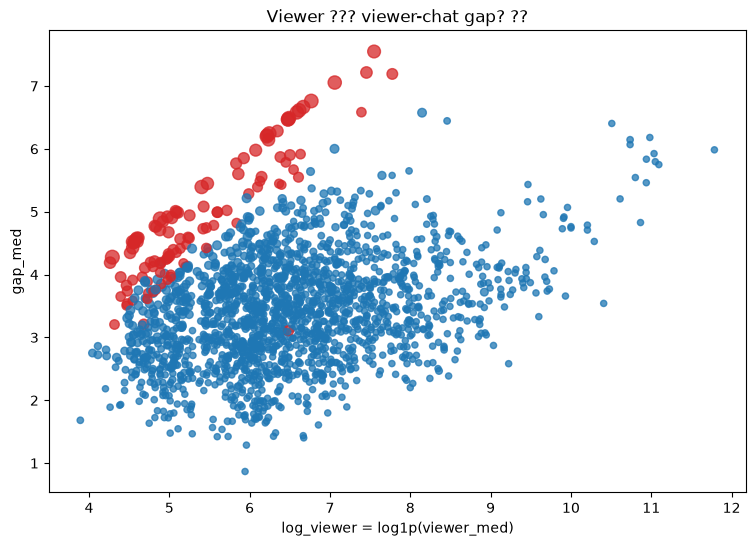

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = session['silver_suspicious'].map({0: 'tab:blue', 1: 'tab:red'})
ax.scatter(
    session['log_viewer'],
    session['gap_med'],
    c=colors,
    s=20 + 80 * session['zero_rate'],
    alpha=0.75,
)
ax.set_xlabel('log_viewer = log1p(viewer_med)')
ax.set_ylabel('gap_med')
ax.set_title('Viewer ??? viewer-chat gap? ??')
plt.show()

## 5. Rule-based Suspicious Score

Using only KMeans labels is fragile, so we also build an interpretable rule score.

The score is the average percentile rank of:

- high `zero_rate`
- high `gap_med`
- high `zrun_max`
- low `chat_mean`
- low `unique_mean`

This score is not a ground truth label. It is a sanity check for whether the KMeans suspicious cluster points in a reasonable direction.

In [10]:
def pct_rank(s, ascending=True):
    return s.rank(pct=True, ascending=ascending, method='average')

session['rule_zero_rate'] = pct_rank(session['zero_rate'], ascending=True)
session['rule_gap_med'] = pct_rank(session['gap_med'], ascending=True)
session['rule_zrun_max'] = pct_rank(session['zrun_max'], ascending=True)
session['rule_low_chat'] = pct_rank(-session['chat_mean'], ascending=True)
session['rule_low_unique'] = pct_rank(-session['unique_mean'], ascending=True)

rule_cols = ['rule_zero_rate', 'rule_gap_med', 'rule_zrun_max', 'rule_low_chat', 'rule_low_unique']
session['rule_suspicious_score'] = session[rule_cols].mean(axis=1)

session[['session_key', 'cluster_number', 'silver_suspicious', 'rule_suspicious_score', *profile_cols]].sort_values(
    'rule_suspicious_score', ascending=False
).head(20)

,session_key,cluster_number,silver_suspicious,rule_suspicious_score,n,viewer_med,viewer_max,chat_mean,unique_mean,zero_rate,zrun_max,gap_med,gap_max,log_viewer,log_chat,log_unique,log_zrun
1174,145_19023370,1,1,0.9983,119,868.0000,933.0000,0.0672,0.0672,0.9328,32,6.7616,6.8395,6.7673,0.0651,0.0651,3.4965
1057,141_18988637,1,1,0.9977,119,657.0000,689.0000,0.1345,0.0756,0.9244,50,6.4877,6.5367,6.4892,0.1262,0.0729,3.9318
944,137_18988637,1,1,0.9974,120,747.0000,806.0000,0.1250,0.1167,0.8917,35,6.6141,6.6933,6.6174,0.1178,0.1103,3.5835
1303,149_19046923,1,1,0.9967,91,650.0000,720.0000,0.1538,0.1099,0.8901,41,6.4708,6.5806,6.4785,0.1431,0.1043,3.7377
126,44_18387423,1,1,0.9959,114,"1,162.5000","1,203.0000",0.2544,0.1404,0.8860,23,7.0553,7.0934,7.0592,0.2266,0.1313,3.1781
1201,146_19023370,1,1,0.9952,119,785.0000,822.0000,0.2269,0.1933,0.8739,22,6.6657,6.7130,6.6670,0.2045,0.1767,3.1355
973,138_18988637,1,1,0.9948,120,725.0000,830.0000,0.1667,0.1583,0.8750,19,6.5793,6.7226,6.5876,0.1542,0.1470,2.9957
86,40_18386889,1,1,0.9946,119,498.0000,602.0000,0.1513,0.1513,0.8655,27,6.1985,6.3969,6.2126,0.1409,0.1409,3.3322
1028,140_18988637,1,1,0.9943,118,649.0000,719.0000,0.4068,0.2458,0.8559,32,6.4661,6.5793,6.4770,0.3413,0.2197,3.4965
116,43_18386889,1,1,0.9930,120,501.0000,518.0000,0.3917,0.2000,0.8250,20,6.2166,6.2519,6.2186,0.3305,0.1823,3.0445


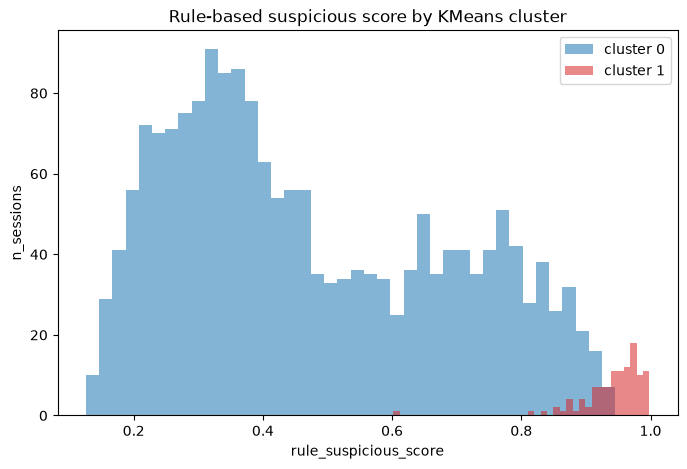

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for c, color in [(0, 'tab:blue'), (1, 'tab:red')]:
    values = session.loc[session['cluster_number'] == c, 'rule_suspicious_score']
    ax.hist(values, bins=40, alpha=0.55, label=f'cluster {c}', color=color)
ax.set_xlabel('rule_suspicious_score')
ax.set_ylabel('n_sessions')
ax.set_title('Rule-based suspicious score by KMeans cluster')
ax.legend()
plt.show()

## 6. Top-k Overlap

In [12]:
rows = []
positive_total = int(session['silver_suspicious'].sum())
for k in [20, 50, 100, positive_total, 200]:
    top = session.nlargest(k, 'rule_suspicious_score')
    rows.append({
        'top_k': k,
        'silver_positive_in_top_k': int(top['silver_suspicious'].sum()),
        'precision_vs_silver': top['silver_suspicious'].mean(),
        'recall_vs_silver': top['silver_suspicious'].sum() / positive_total,
    })

overlap_table = pd.DataFrame(rows)
overlap_table

,top_k,silver_positive_in_top_k,precision_vs_silver,recall_vs_silver
0,20,20,1.0000,0.1802
1,50,50,1.0000,0.4505
2,100,88,0.8800,0.7928
3,111,93,0.8378,0.8378
4,200,108,0.5400,0.9730


## 7. Save Intermediate Output

The session table with the rule-based suspiciousness score is saved for later notebooks.

In [13]:
out_path = OUTPUT_DIR / 'session_with_rule_score.csv'
session.to_csv(out_path, index=False, encoding='utf-8-sig')
out_path

WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/session_with_rule_score.csv')